In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
SEED = 42
import random
random.seed(SEED)
import torch
torch.manual_seed(SEED)

import yaml
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from torchinfo import summary
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

from modules.datamodule import LungSoundDataModule
from modules.classifier import LungSoundClassifier
from modules.transforms import *

In [2]:
PROJECT_ROOT = Path(os.path.dirname(os.getcwd()))
DATA_FOLDER = PROJECT_ROOT / "data" / "preprocessed"
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

EXPERIMENTS_FOLDER = PROJECT_ROOT / "experiments"
if not os.path.exists(EXPERIMENTS_FOLDER):
    print(f"Experiments directory not found at {EXPERIMENTS_FOLDER}. Please ensure the experiment configuration files are placed in the correct location.")

LOGS_FOLDER = PROJECT_ROOT / "logs"
if not os.path.exists(LOGS_FOLDER):
    os.makedirs(LOGS_FOLDER)

CHECKPOINTS_FOLDER = PROJECT_ROOT / "checkpoints"
if not os.path.exists(CHECKPOINTS_FOLDER):
    os.makedirs(CHECKPOINTS_FOLDER)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

torch.set_float32_matmul_precision("high")
%load_ext tensorboard

Using device: cuda


In [3]:
def get_input_size(dm: LungSoundDataModule) -> tuple:
    """
    Get the input size for the model based on a sample batch from the DataModule.
    Args:
        dm (LungSoundDataModule): The DataModule to sample from.
    Returns:
        input_size (tuple): Tuple representing the shape of the input data (e.g., (B, C, H, W)).
    """
    dm.setup()
    loader = dm.train_dataloader()
    batch = next(iter(loader))
    inputs, _ = batch
    return tuple(inputs.shape)


def train_model(hparams: dict, debug: bool = False) -> LungSoundClassifier:
    """
    Train a model.
    Args:
        hparams (dict): Hyperparameters and configuration for the experiment. Trainer parameters:
        ```
        - experiment (str): Name of the experiment for logging and checkpointing.
        - checkpoint_monitor (str): Metric to monitor for checkpointing (e.g., "val_loss").
        - checkpoint_mode (str): Mode for checkpointing ("min" or "max").
        - early_stop_monitor (str): Metric to monitor for early stopping (e.g., "val_loss").
        - early_stop_mode (str): Mode for early stopping ("min" or "max").
        - patience (int): Number of epochs with no improvement after which training will be stopped.
        - max_epochs (int): Maximum number of training epochs.
        - precision (int): Precision for training (e.g., 16 for mixed precision).
        ```
        debug (bool): If True, dry run the training for quick debugging. Default is False.
    Returns:
        model (LungSoundClassifier): The trained model.
    """
    # Initialize logger
    logger = TensorBoardLogger(
        save_dir=LOGS_FOLDER,
        name=hparams["experiment"],
    )

    # Initialize callbacks
    callbacks = []
    if not debug:
        checkpoint_callback = ModelCheckpoint(
            dirpath=CHECKPOINTS_FOLDER,
            filename=hparams["experiment"] + "-{epoch}-{val_loss:.2f}-{val_f1_micro:.2f}-{val_f1_macro:.2f}",
            monitor=hparams["checkpoint_monitor"],
            mode=hparams["checkpoint_mode"],
            save_top_k=3,
            verbose=True,
        )
        callbacks.append(checkpoint_callback)

        early_stopping_callback = EarlyStopping(
            monitor=hparams["early_stop_monitor"],
            mode=hparams["early_stop_mode"],
            patience=hparams["patience"],
            verbose=True,
        )
        callbacks.append(early_stopping_callback)

    # Initialize DataModule and Model
    dm = LungSoundDataModule(hparams, DATA_FOLDER)
    model = LungSoundClassifier(hparams)

    # Display model architecture
    input_shape = get_input_size(dm)
    print("Model Summary:\n")
    print(f"Input shape: {input_shape}")
    print(summary(model, input_size=input_shape))
    print("\n")

    # Initialize Trainer
    trainer = Trainer(
        accelerator="gpu" if DEVICE == "cuda" else "cpu",
        devices="auto",
        max_epochs=hparams["max_epochs"],
        precision=hparams["precision"],
        callbacks=callbacks,
        logger=logger,
        fast_dev_run=debug,
    )

    # Train the model
    trainer.fit(model, dm)
    return model

In [ ]:
def show_metrics(targets: np.ndarray, preds: np.ndarray, probs: np.ndarray, class_names: list):
    """
    Display classification metrics including classification report, ROC AUC curve, Precision-Recall curve, and confusion matrix.
    Args:
        targets (np.ndarray): Array of true target labels.
        preds (np.ndarray): Array of predicted labels by the model.
        probs (np.ndarray): Array of predicted probabilities for each class.
        class_names (list): List of class names corresponding to the target labels.
    """
    # y_true in one-hot encoding format for multi-class metrics
    y_true = label_binarize(targets, classes=np.arange(len(class_names)))

    # Print classification report
    print("Classification Report:")
    print(classification_report(targets, preds, target_names=class_names))

    # Plot ROC curves
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, class_name in enumerate(class_names):
        RocCurveDisplay.from_predictions(y_true[:, i], probs[:, i], name=class_name, ax=ax)
    ax.set_title("ROC Curves")
    plt.show()

    # Plot Precision-Recall curves
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, class_name in enumerate(class_names):
        PrecisionRecallDisplay.from_predictions(y_true[:, i], probs[:, i], name=class_name, ax=ax)
    ax.set_title("Precision-Recall Curves")
    plt.show()

    # Plot confusion matrix
    cm = confusion_matrix(targets, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()


def evaluate_model(model: LungSoundClassifier):
    """
    Evaluate the model on the test set and display metrics.
    Args:
        model (LungSoundClassifier): The trained model to evaluate.
    """
    hparams = model.hparams
    dm = LungSoundDataModule(hparams, DATA_FOLDER)
    trainer = Trainer(
        accelerator="gpu" if DEVICE == "cuda" else "cpu",
        devices="auto",
        precision=hparams["precision"],
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        enable_model_summary=False,
    )
    trainer.test(model, dm)
    targets = np.asarray(model.test_results["targets"])
    preds = np.asarray(model.test_results["preds"])
    probs = np.asarray(model.test_results["probs"])
    class_names = hparams.dataset["classes"]
    show_metrics(targets, preds, probs, class_names)

In [5]:
def load_hyperparameters(config_path: str) -> dict:
    """
    Load hyperparameters from a YAML configuration file.
    Args:
        config_path (str): Path to the YAML configuration file.
    Returns:
        hparams (dict): Dictionary containing the hyperparameters and configuration.
    """
    with open(config_path, "r") as file:
        hparams = yaml.safe_load(file)
    print("Experiment hyperparameters:")
    for key, value in hparams.items():
        print(f"\t{key}: {value}")
    print("\n")
    return hparams

## First Run

In [6]:
experiment_file = EXPERIMENTS_FOLDER / "resnet18_first_run.yml"
hparams = load_hyperparameters(experiment_file)

Experiment hyperparameters:
	experiment: resnet18_first_run
	checkpoint_monitor: val_f1_macro
	checkpoint_mode: max
	early_stop_monitor: val_f1_macro
	early_stop_mode: max
	patience: 10
	max_epochs: 100
	precision: 16-mixed
	seed: 42
	batch_size: 32
	num_workers: 4
	sampler: None
	model: {'name': 'resnet18', 'architecture': 'cnn', 'pretrained': None, 'freeze_layers': False}
	criterion: CrossEntropyLoss
	optimizer: AdamW
	learning_rate: 0.0001
	weight_decay: 1e-05
	momentum: None
	lr_scheduler: StepLR
	step_size: 7
	gamma: 0.1
	dataset: {'name': 'combined', 'classes': ['Asthma', 'Bronchiectasis', 'Bronchiolitis', 'COPD', 'Healthy', 'Lung Fibrosis', 'Pneumonia', 'URTI'], 'num_channels': 1, 'preprocess': [{'Window': {'window_length': 5, 'hop_length': 5}}, {'Resample': {'target_sr': 22050}}, {'NormalizeAudio': {}}]}
	transforms: [{'Spectrogram': {'n_fft': 2048, 'hop_length': 512}}]




In [ ]:
model = train_model(hparams, debug=False)

Model Summary:

--------------------------------------------------


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name           | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------------
0  | model          | ResNet             | 11.2 M | train | 0    
1  | criterion      | CrossEntropyLoss   | 0      | train | 0    
2  | train_f1_macro | MulticlassF1Score  | 0      | train | 0 

Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [32, 8]                   --
├─ResNet: 1-1                                 [32, 8]                   --
│    └─Conv2d: 2-1                            [32, 64, 513, 108]        3,136
│    └─BatchNorm2d: 2-2                       [32, 64, 513, 108]        128
│    └─ReLU: 2-3                              [32, 64, 513, 108]        --
│    └─MaxPool2d: 2-4                         [32, 64, 257, 54]         --
│    └─Sequential: 2-5                        [32, 64, 257, 54]         --
│    │    └─BasicBlock: 3-1                   [32, 64, 257, 54]         73,984
│    │    └─BasicBlock: 3-2                   [32, 64, 257, 54]         73,984
│    └─Sequential: 2-6                        [32, 128, 129, 27]        --
│    │    └─BasicBlock: 3-3                   [32, 128, 129, 27]        230,144
│    │    └─BasicBlock: 3-4                   [32, 128, 129, 27]        295,42

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Epoch 19, global step 2340: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 20, global step 2457: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.652. Signaling Trainer to stop.
Epoch 21, global step 2574: 'val_f1_macro' was not in top 3


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 18. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         Test metric                 DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_Asthma_f1             0.7407407164573669
    test_Asthma_precision          0.800000011920929
     test_Asthma_recall           0.6896551847457886
   test_Bronchiectasis_f1         0.9090909361839294
test_Bronchiectasis_precision             1.0
 test_Bronchiectasis_recall       0.8333333134651184
    test_Bronchiolitis_f1         0.4444444477558136
test_Bronchiolitis_precision              0.5
  test_Bronchiolitis_recall       0.4000000059604645
        test_COPD_f1              0.9469273686408997
     test_COPD_precision          0.9237056970596313
      test_COPD_recall            0.9713466763496399
       test_Healthy_f1            0.6947368383407593
   test_Healthy_precision        

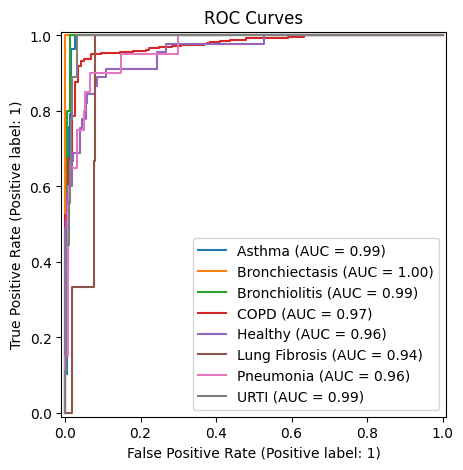

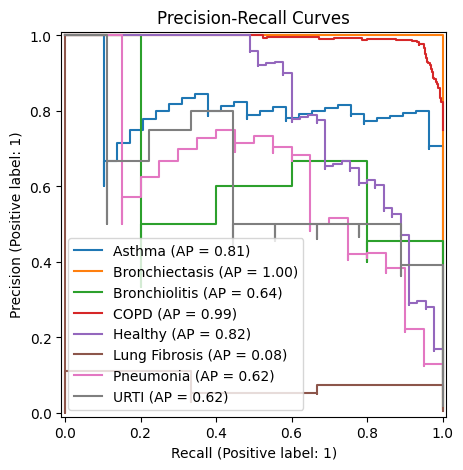

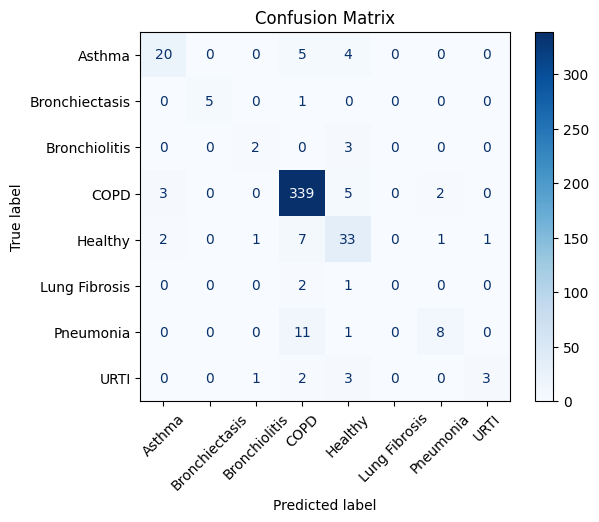

In [11]:
evaluate_model(model)

## Resnet 18 using Spectogram (STFT only)

In [6]:
experiment_file = EXPERIMENTS_FOLDER / "resnets" / "resnet18_combined_8-classes_spectogram.yml"
hparams = load_hyperparameters(experiment_file)
model = train_model(hparams, debug=False)

Experiment hyperparameters:
	experiment: resenet18_combined_8-classes_spectogram
	checkpoint_monitor: val_f1_macro
	checkpoint_mode: max
	early_stop_monitor: val_f1_macro
	early_stop_mode: max
	patience: 10
	max_epochs: 100
	precision: 16-mixed
	seed: 42
	batch_size: 32
	num_workers: 4
	sampler: None
	model: {'name': 'resnet18', 'architecture': 'cnn', 'pretrained': None, 'freeze_layers': False}
	criterion: CrossEntropyLoss
	optimizer: AdamW
	learning_rate: 0.0001
	weight_decay: 1e-05
	momentum: None
	lr_scheduler: StepLR
	step_size: 7
	gamma: 0.1
	dataset: {'name': 'combined', 'classes': ['Asthma', 'Bronchiectasis', 'Bronchiolitis', 'COPD', 'Healthy', 'Lung Fibrosis', 'Pneumonia', 'URTI'], 'num_channels': 1, 'preprocess': [{'Window': {'window_length': 5, 'hop_length': 5}}, {'Resample': {'target_sr': 22050}}, {'NormalizeAudio': {}}]}
	transforms: [{'Spectrogram': {'n_fft': 2048, 'hop_length': 512}}]


Model Summary:

Input shape: (32, 1, 1025, 216)


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/leticialopes/projects/IA901/IA901_Project/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name           | Type               | Params | Mode  | FLOPs
-------------------------------

Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [32, 8]                   --
├─ResNet: 1-1                                 [32, 8]                   --
│    └─Conv2d: 2-1                            [32, 64, 513, 108]        3,136
│    └─BatchNorm2d: 2-2                       [32, 64, 513, 108]        128
│    └─ReLU: 2-3                              [32, 64, 513, 108]        --
│    └─MaxPool2d: 2-4                         [32, 64, 257, 54]         --
│    └─Sequential: 2-5                        [32, 64, 257, 54]         --
│    │    └─BasicBlock: 3-1                   [32, 64, 257, 54]         73,984
│    │    └─BasicBlock: 3-2                   [32, 64, 257, 54]         73,984
│    └─Sequential: 2-6                        [32, 128, 129, 27]        --
│    │    └─BasicBlock: 3-3                   [32, 128, 129, 27]        230,144
│    │    └─BasicBlock: 3-4                   [32, 128, 129, 27]        295,42

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Epoch 24, global step 2925: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 25, global step 3042: 'val_f1_macro' reached 0.66414 (best 0.67109), saving model to '/home/leticialopes/projects/IA901/IA901_Project/checkpoints/resenet18_combined_8-classes_spectogram-epoch=25-val_loss=0.31-val_f1_micro=0.89-val_f1_macro=0.66.ckpt' as top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.671. Signaling Trainer to stop.
Epoch 26, global step 3159: 'val_f1_macro' reached 0.66803 (best 0.67109), saving model to '/home/leticialopes/projects/IA901/IA901_Project/checkpoints/resenet18_combined_8-classes_spectogram-epoch=26-val_loss=0.32-val_f1_micro=0.89-val_f1_macro=0.67.ckpt' as top 3


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 18. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         Test metric                 DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_Asthma_f1             0.8518518805503845
    test_Asthma_precision         0.9200000166893005
     test_Asthma_recall           0.7931034564971924
   test_Bronchiectasis_f1                 0.5
test_Bronchiectasis_precision             1.0
 test_Bronchiectasis_recall       0.3333333432674408
    test_Bronchiolitis_f1                0.25
test_Bronchiolitis_precision      0.3333333432674408
  test_Bronchiolitis_recall       0.20000000298023224
        test_COPD_f1              0.9510489702224731
     test_COPD_precision          0.9289617538452148
      test_COPD_recall            0.9742120504379272
       test_Healthy_f1            0.7586206793785095
   test_Healthy_precision         0.785

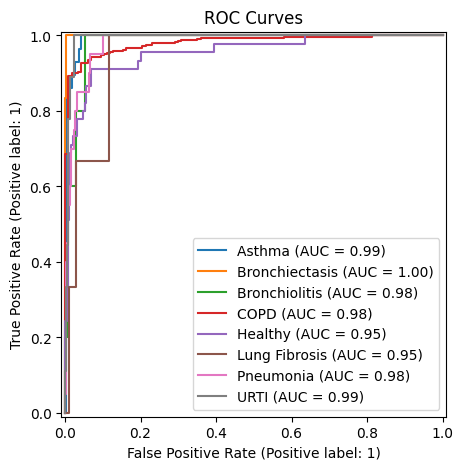

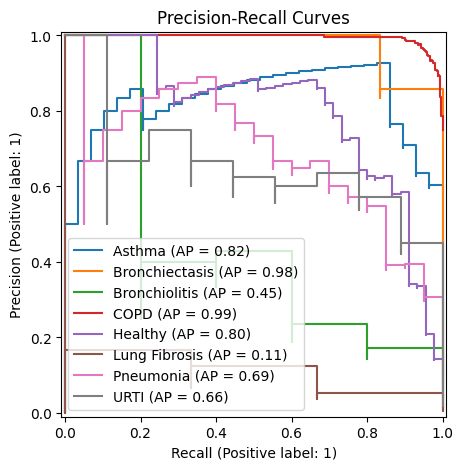

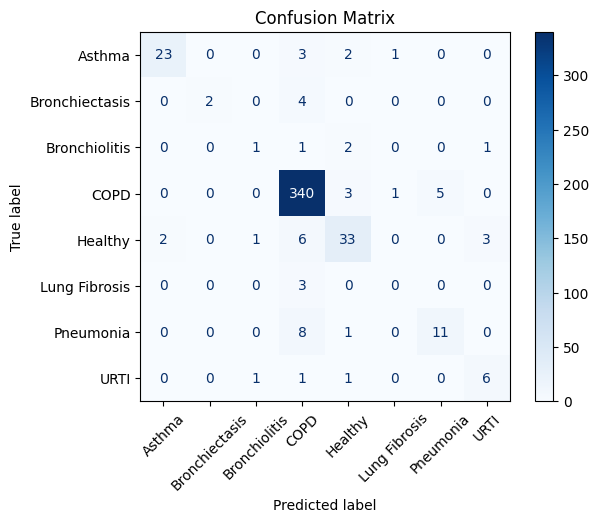

In [7]:
evaluate_model(model)

## Resnet 18 using Mel Spectogram

In [8]:
experiment_file = EXPERIMENTS_FOLDER / "resnets" / "resnet18_combined_8-classes_mel-spectogram.yml"
hparams = load_hyperparameters(experiment_file)
model = train_model(hparams)

Experiment hyperparameters:
	experiment: resenet18_combined_8-classes_mel-spectogram
	checkpoint_monitor: val_f1_macro
	checkpoint_mode: max
	early_stop_monitor: val_f1_macro
	early_stop_mode: max
	patience: 10
	max_epochs: 100
	precision: 16-mixed
	seed: 42
	batch_size: 32
	num_workers: 4
	sampler: None
	model: {'name': 'resnet18', 'architecture': 'cnn', 'pretrained': None, 'freeze_layers': False}
	criterion: CrossEntropyLoss
	optimizer: AdamW
	learning_rate: 0.0001
	weight_decay: 1e-05
	momentum: None
	lr_scheduler: StepLR
	step_size: 7
	gamma: 0.1
	dataset: {'name': 'combined', 'classes': ['Asthma', 'Bronchiectasis', 'Bronchiolitis', 'COPD', 'Healthy', 'Lung Fibrosis', 'Pneumonia', 'URTI'], 'num_channels': 1, 'preprocess': [{'Window': {'window_length': 5, 'hop_length': 5}}, {'Resample': {'target_sr': 22050}}, {'NormalizeAudio': {}}]}
	transforms: [{'MelSpectrogram': {'n_fft': 2048, 'hop_length': 512, 'n_mels': 128}}]




Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/leticialopes/projects/IA901/IA901_Project/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name           | Type               | Params | Mode  | FLOPs
-------------------------------

Model Summary:

Input shape: (32, 1, 128, 216)
Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [32, 8]                   --
├─ResNet: 1-1                                 [32, 8]                   --
│    └─Conv2d: 2-1                            [32, 64, 64, 108]         3,136
│    └─BatchNorm2d: 2-2                       [32, 64, 64, 108]         128
│    └─ReLU: 2-3                              [32, 64, 64, 108]         --
│    └─MaxPool2d: 2-4                         [32, 64, 32, 54]          --
│    └─Sequential: 2-5                        [32, 64, 32, 54]          --
│    │    └─BasicBlock: 3-1                   [32, 64, 32, 54]          73,984
│    │    └─BasicBlock: 3-2                   [32, 64, 32, 54]          73,984
│    └─Sequential: 2-6                        [32, 128, 16, 27]         --
│    │    └─BasicBlock: 3-3                   [32, 128, 16, 27]         230,144
│    │    └─BasicBlock: 3-4    

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Epoch 35, global step 4212: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 36, global step 4329: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.799. Signaling Trainer to stop.
Epoch 37, global step 4446: 'val_f1_macro' reached 0.79390 (best 0.79891), saving model to '/home/leticialopes/projects/IA901/IA901_Project/checkpoints/resenet18_combined_8-classes_mel-spectogram-epoch=37-val_loss=0.24-val_f1_micro=0.93-val_f1_macro=0.79.ckpt' as top 3


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         Test metric                 DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_Asthma_f1             0.7692307829856873
    test_Asthma_precision         0.8695651888847351
     test_Asthma_recall           0.6896551847457886
   test_Bronchiectasis_f1         0.9090909361839294
test_Bronchiectasis_precision             1.0
 test_Bronchiectasis_recall       0.8333333134651184
    test_Bronchiolitis_f1         0.6000000238418579
test_Bronchiolitis_precision      0.6000000238418579
  test_Bronchiolitis_recall       0.6000000238418579
        test_COPD_f1              0.9815078377723694
     test_COPD_precision          0.9745762944221497
      test_COPD_recall            0.9885386824607849
       test_Healthy_f1                   0.75
   test_Healthy_precision        

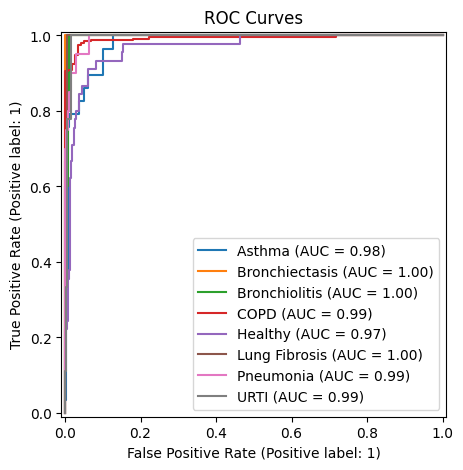

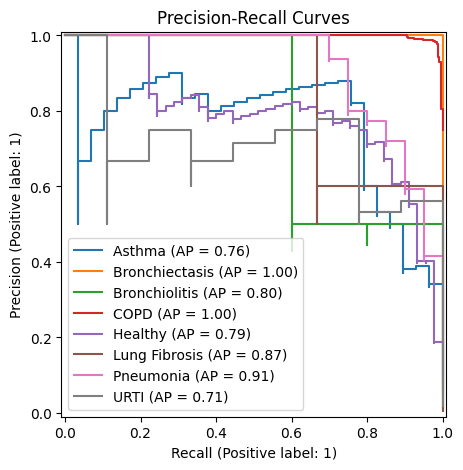

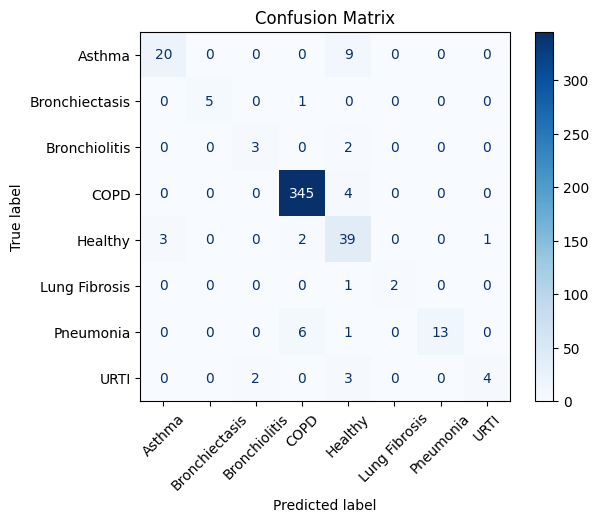

In [9]:
evaluate_model(model)

In [ ]:
%tensorboard --logdir {LOGS_FOLDER}